**Corpora Exploration**

In [61]:
import nltk


nltk.download('gutenberg')
nltk.download('reuters')
nltk.download('webtext')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package webtext to /root/nltk_data...
[nltk_data]   Package webtext is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [62]:
from nltk.corpus import gutenberg

print(gutenberg.fileids())

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


In [63]:
hamlet = gutenberg.words('shakespeare-hamlet.txt')

print(hamlet[:30])

['[', 'The', 'Tragedie', 'of', 'Hamlet', 'by', 'William', 'Shakespeare', '1599', ']', 'Actus', 'Primus', '.', 'Scoena', 'Prima', '.', 'Enter', 'Barnardo', 'and', 'Francisco', 'two', 'Centinels', '.', 'Barnardo', '.', 'Who', "'", 's', 'there', '?']


In [64]:
print(len(hamlet))

37360


In [65]:
from nltk import FreqDist

dist = FreqDist(hamlet)
print(dist)
print(len(dist))
print(dist['hamlet'])

<FreqDist with 5447 samples and 37360 outcomes>
5447
0


In [66]:
print(dist.most_common(10))

[(',', 2892), ('.', 1886), ('the', 860), ("'", 729), ('and', 606), ('of', 576), ('to', 576), (':', 565), ('I', 553), ('you', 479)]


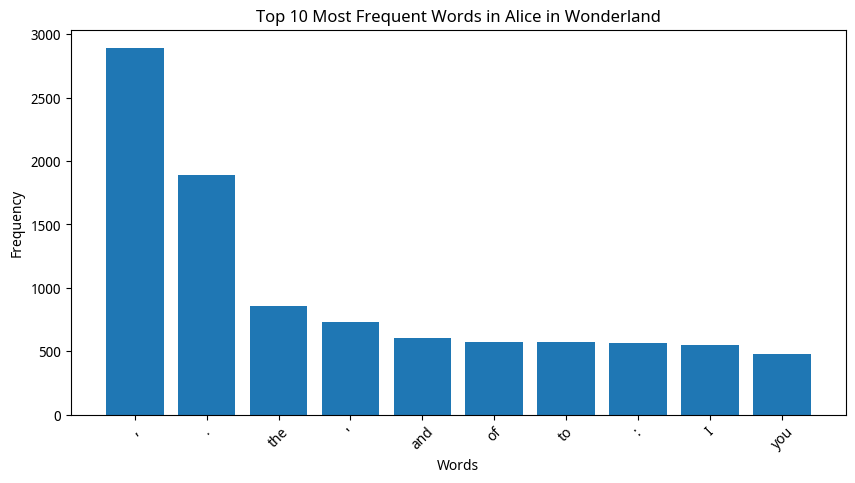

In [67]:
import matplotlib.pyplot as plt

top_words = dist.most_common(10)

words = [word for word, freq in top_words]
counts = [freq for word, freq in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.title("Top 10 Most Frequent Words in Alice in Wonderland")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.show()

In [68]:
import nltk
nltk.download('nps_chat')

from nltk.corpus import nps_chat


print(nps_chat.fileids())

words = nps_chat.words()

print(words[:50])


print("Total words:", len(words))
print("Unique words:", len(set(words)))

[nltk_data] Downloading package nps_chat to /root/nltk_data...
[nltk_data]   Package nps_chat is already up-to-date!


['10-19-20s_706posts.xml', '10-19-30s_705posts.xml', '10-19-40s_686posts.xml', '10-19-adults_706posts.xml', '10-24-40s_706posts.xml', '10-26-teens_706posts.xml', '11-06-adults_706posts.xml', '11-08-20s_705posts.xml', '11-08-40s_706posts.xml', '11-08-adults_705posts.xml', '11-08-teens_706posts.xml', '11-09-20s_706posts.xml', '11-09-40s_706posts.xml', '11-09-adults_706posts.xml', '11-09-teens_706posts.xml']
['now', 'im', 'left', 'with', 'this', 'gay', 'name', ':P', 'PART', 'hey', 'everyone', 'ah', 'well', 'NICK', ':', 'U7', 'U7', 'is', 'a', 'gay', 'name', '.', '.', 'ACTION', 'gives', 'U121', 'a', 'golf', 'clap', '.', ':)', 'JOIN', 'hi', 'U59', '26', '/', 'm', '/', 'ky', 'women', 'that', 'are', 'nice', 'please', 'pm', 'me', 'JOIN', 'PART', 'there', 'ya']
Total words: 45010
Unique words: 6066


In [69]:
posts = nps_chat.posts()

print("Total chat posts:", len(posts))
print(posts[:3])

Total chat posts: 10567
[['now', 'im', 'left', 'with', 'this', 'gay', 'name'], [':P'], ['PART']]


In [112]:
sample_post = " ".join(posts[0])

print("Original Post:")
print(sample_post)

Original Post:
now im left with this gay name


In [113]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(sample_post)

print(tokens)

['now', 'im', 'left', 'with', 'this', 'gay', 'name']


In [114]:
lower_tokens = [word.lower() for word in tokens]

print("Lowercase Tokens:")
print(lower_tokens)

Lowercase Tokens:
['now', 'im', 'left', 'with', 'this', 'gay', 'name']


In [115]:
clean_tokens = [word for word in lower_tokens if word.isalpha()]

print("Clean Tokens:")
print(clean_tokens)

Clean Tokens:
['now', 'im', 'left', 'with', 'this', 'gay', 'name']


In [116]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

filtered_tokens = [
    word for word in clean_tokens
    if word not in stop_words
]

print("After Stopword Removal:")
print(filtered_tokens)

After Stopword Removal:
['im', 'left', 'gay', 'name']


In [117]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in filtered_tokens]

print("After Stemming:")
print(stemmed_words)

After Stemming:
['im', 'left', 'gay', 'name']


In [118]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_tokens]

print("After Lemmatization:")
print(lemmatized_words)

After Lemmatization:
['im', 'left', 'gay', 'name']


[nltk_data] Downloading package nps_chat to /root/nltk_data...
[nltk_data]   Package nps_chat is already up-to-date!


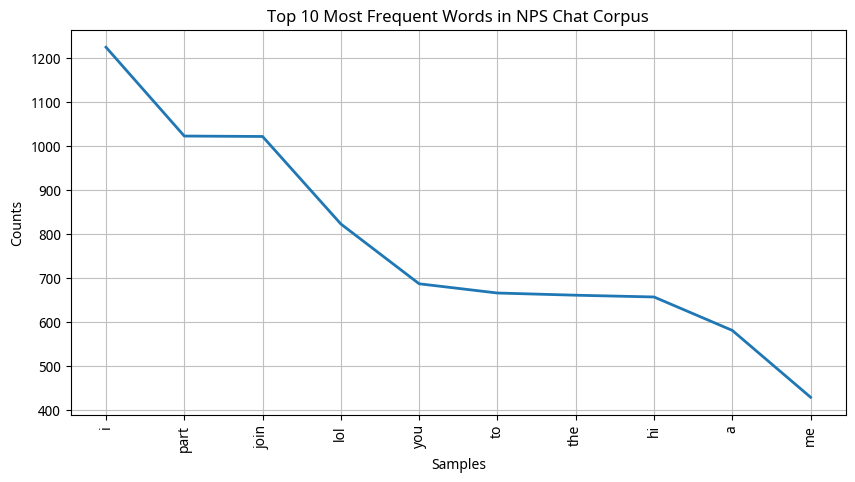

In [70]:
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import nps_chat
from nltk import FreqDist

nltk.download('nps_chat')

words = [word.lower() for word in nps_chat.words() if word.isalpha()]

fdist = FreqDist(words)


plt.figure(figsize=(10, 5))
fdist.plot(10, title="Top 10 Most Frequent Words in NPS Chat Corpus")
plt.show()

In [72]:
from nltk.corpus import reuters

print(reuters.fileids()[:20])

print(reuters.words(reuters.fileids()[0])[:20])

print(reuters.raw(reuters.fileids()[0])[:300])

print(len(reuters.words(reuters.fileids()[0])))

print(reuters.sents(reuters.fileids()[0])[:3])

['test/14826', 'test/14828', 'test/14829', 'test/14832', 'test/14833', 'test/14839', 'test/14840', 'test/14841', 'test/14842', 'test/14843', 'test/14844', 'test/14849', 'test/14852', 'test/14854', 'test/14858', 'test/14859', 'test/14860', 'test/14861', 'test/14862', 'test/14863']
['ASIAN', 'EXPORTERS', 'FEAR', 'DAMAGE', 'FROM', 'U', '.', 'S', '.-', 'JAPAN', 'RIFT', 'Mounting', 'trade', 'friction', 'between', 'the', 'U', '.', 'S', '.']
ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
  Mounting trade friction between the
  U.S. And Japan has raised fears among many of Asia's exporting
  nations that the row could inflict far-reaching economic
  damage, businessmen and officials said.
      They told Reuter correspondents in Asian 
899
[['ASIAN', 'EXPORTERS', 'FEAR', 'DAMAGE', 'FROM', 'U', '.', 'S', '.-', 'JAPAN', 'RIFT', 'Mounting', 'trade', 'friction', 'between', 'the', 'U', '.', 'S', '.', 'And', 'Japan', 'has', 'raised', 'fears', 'among', 'many', 'of', 'Asia', "'", 's', 'exporting', '

In [73]:
import nltk
nltk.download('movie_reviews')

from nltk.corpus import movie_reviews

print(movie_reviews.categories())


print(movie_reviews.fileids()[:20])

words = movie_reviews.words()

print("First 50 words:")
print(words[:50])

print("\nTotal words:", len(words))
print("Unique words:", len(set(words)))

['neg', 'pos']
['neg/cv000_29416.txt', 'neg/cv001_19502.txt', 'neg/cv002_17424.txt', 'neg/cv003_12683.txt', 'neg/cv004_12641.txt', 'neg/cv005_29357.txt', 'neg/cv006_17022.txt', 'neg/cv007_4992.txt', 'neg/cv008_29326.txt', 'neg/cv009_29417.txt', 'neg/cv010_29063.txt', 'neg/cv011_13044.txt', 'neg/cv012_29411.txt', 'neg/cv013_10494.txt', 'neg/cv014_15600.txt', 'neg/cv015_29356.txt', 'neg/cv016_4348.txt', 'neg/cv017_23487.txt', 'neg/cv018_21672.txt', 'neg/cv019_16117.txt']


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


First 50 words:
['plot', ':', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', ',', 'drink', 'and', 'then', 'drive', '.', 'they', 'get', 'into', 'an', 'accident', '.', 'one', 'of', 'the', 'guys', 'dies', ',', 'but', 'his', 'girlfriend', 'continues', 'to', 'see', 'him', 'in', 'her', 'life', ',', 'and', 'has', 'nightmares', '.', 'what', "'", 's', 'the', 'deal', '?', 'watch']

Total words: 1583820
Unique words: 39768


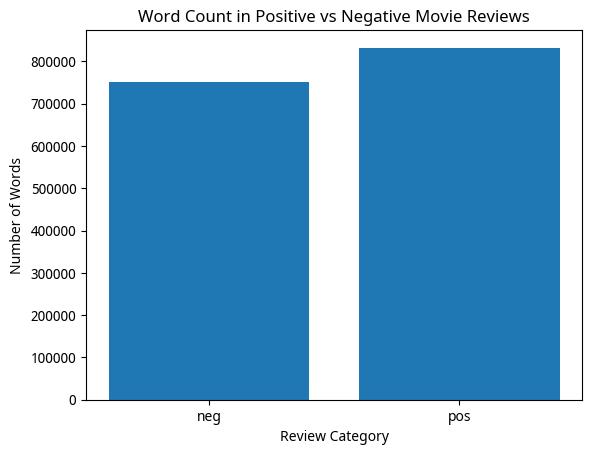

In [74]:
import matplotlib.pyplot as plt
from nltk.corpus import movie_reviews

categories = movie_reviews.categories()

word_counts = [
    len(movie_reviews.words(categories=category))
    for category in categories
]

plt.bar(categories, word_counts)
plt.xlabel("Review Category")
plt.ylabel("Number of Words")
plt.title("Word Count in Positive vs Negative Movie Reviews")
plt.show()

In [80]:
import nltk
nltk.download('indian')

[nltk_data] Downloading package indian to /root/nltk_data...
[nltk_data]   Package indian is already up-to-date!


True

In [81]:
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
font_url = "https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf"
font_path = "NotoSansDevanagari.ttf"
urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font_prop.get_name(), 'DejaVu Sans', 'Arial'] + plt.rcParams['font.sans-serif']
plt.rcParams["axes.unicode_minus"] = False


In [82]:
from nltk.corpus import indian
print(indian.fileids())

['bangla.pos', 'hindi.pos', 'marathi.pos', 'telugu.pos']


In [83]:
hindi=indian.words('hindi.pos')
print(hindi[:10])


['पूर्ण', 'प्रतिबंध', 'हटाओ', ':', 'इराक', 'संयुक्त', 'राष्ट्र', '।', 'इराक', 'के']


In [84]:
marathi=indian.words('marathi.pos')
print(marathi[:10])

["''", 'सनातनवाद्यांनी', 'व', 'प्रतिगाम्यांनी', 'समाज', 'रसातळाला', 'नेला', 'असताना', 'या', 'अंधारात']


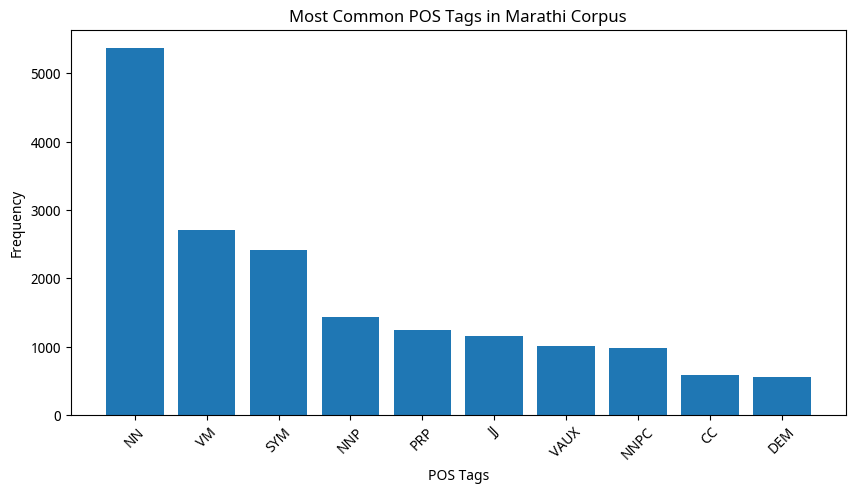

In [85]:
from nltk.corpus import indian
from nltk import FreqDist
import matplotlib.pyplot as plt

marathi = indian.tagged_words('marathi.pos')

fd_marathi = FreqDist(tag for word, tag in marathi)

common = fd_marathi.most_common(10)

tags = [x[0] for x in common]
counts = [x[1] for x in common]

plt.figure(figsize=(10,5))
plt.bar(tags, counts)

plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.title("Most Common POS Tags in Marathi Corpus")

plt.xticks(rotation=45)
plt.show()

In [86]:
telugu=indian.words('telugu.pos')
print(telugu[:10])

['4', '.', 'ఆడిట్', 'నిర్వహణ', 'ఆడిటర్', 'ఒక', 'కొత్త', 'ఆడిట్', 'చేపట్టే', 'ముందు']


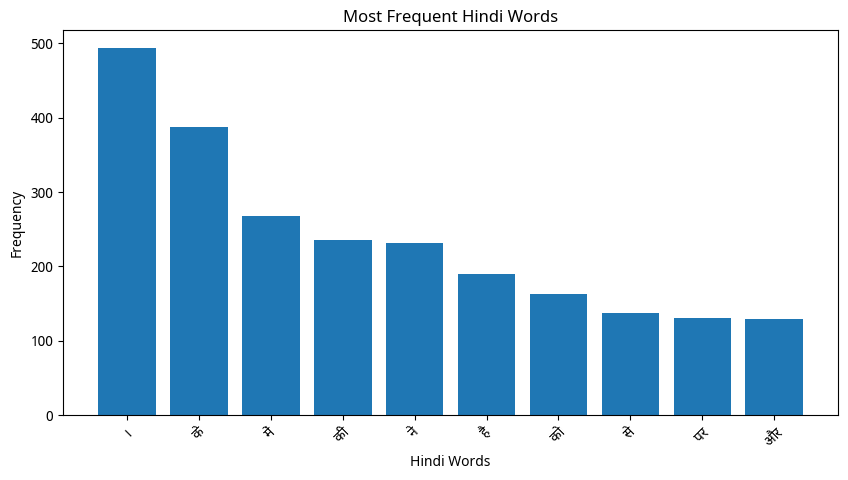

In [87]:
from nltk import FreqDist
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font = fm.FontProperties(fname="NotoSansDevanagari.ttf")

fd = FreqDist(hindi)
common = fd.most_common(10)

words = [x[0] for x in common]
counts = [x[1] for x in common]

plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.xlabel("Hindi Words", fontproperties=font)
plt.ylabel("Frequency")
plt.title("Most Frequent Hindi Words")

plt.xticks(rotation=45, fontproperties=font)
plt.show()

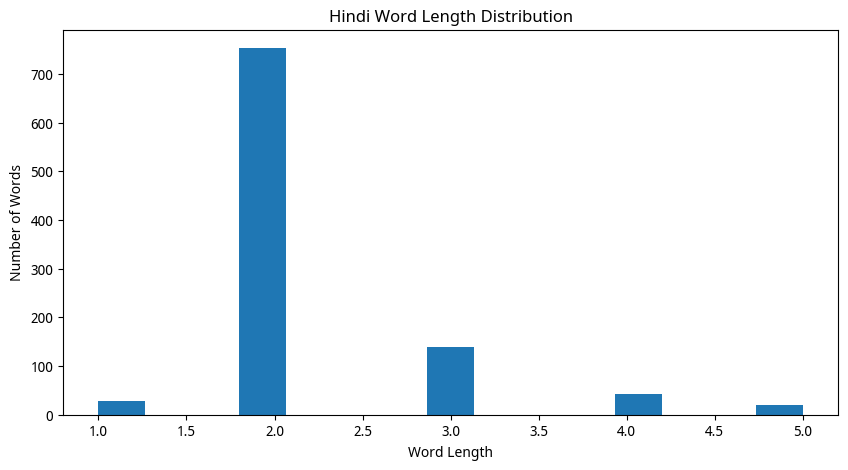

In [88]:
lengths = [len(word) for word in hindi if word.isalpha()]

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=15)

plt.xlabel("Word Length")
plt.ylabel("Number of Words")
plt.title("Hindi Word Length Distribution")
plt.show()

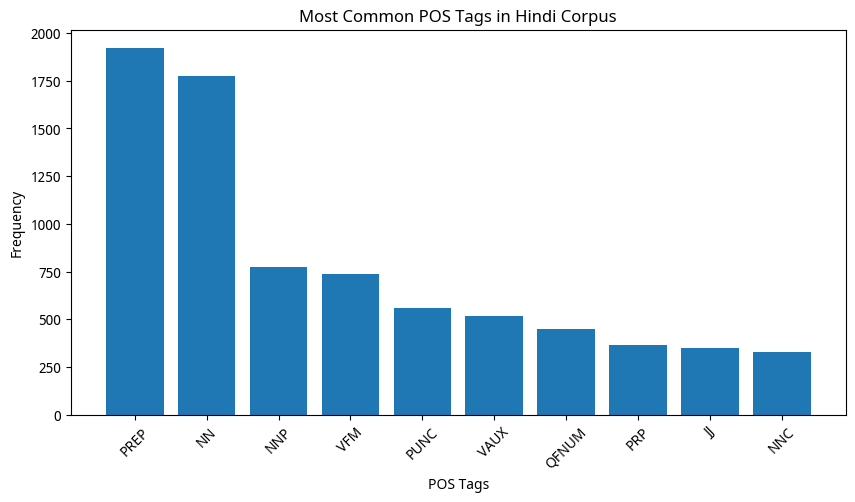

In [89]:
tagged_hindi = indian.tagged_words('hindi.pos')

fd_pos = FreqDist(tag for word, tag in tagged_hindi)

common = fd_pos.most_common(10)

tags = [x[0] for x in common]
counts = [x[1] for x in common]

plt.figure(figsize=(10,5))
plt.bar(tags, counts)

plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.title("Most Common POS Tags in Hindi Corpus")

plt.xticks(rotation=45)
plt.show()

In [90]:
nltk.download('inaugural')
from nltk.corpus import inaugural

[nltk_data] Downloading package inaugural to /root/nltk_data...
[nltk_data]   Unzipping corpora/inaugural.zip.


In [91]:
import nltk

nltk.download('inaugural')

from nltk.corpus import inaugural

print(inaugural.fileids()[:10])

words = inaugural.words()

print(words[:50])

print("Total words:", len(words))
print("Unique words:", len(set(words)))

[nltk_data] Downloading package inaugural to /root/nltk_data...
[nltk_data]   Package inaugural is already up-to-date!


['1789-Washington.txt', '1793-Washington.txt', '1797-Adams.txt', '1801-Jefferson.txt', '1805-Jefferson.txt', '1809-Madison.txt', '1813-Madison.txt', '1817-Monroe.txt', '1821-Monroe.txt', '1825-Adams.txt']
['Fellow', '-', 'Citizens', 'of', 'the', 'Senate', 'and', 'of', 'the', 'House', 'of', 'Representatives', ':', 'Among', 'the', 'vicissitudes', 'incident', 'to', 'life', 'no', 'event', 'could', 'have', 'filled', 'me', 'with', 'greater', 'anxieties', 'than', 'that', 'of', 'which', 'the', 'notification', 'was', 'transmitted', 'by', 'your', 'order', ',', 'and', 'received', 'on', 'the', '14th', 'day', 'of', 'the', 'present', 'month']
Total words: 156288
Unique words: 10200


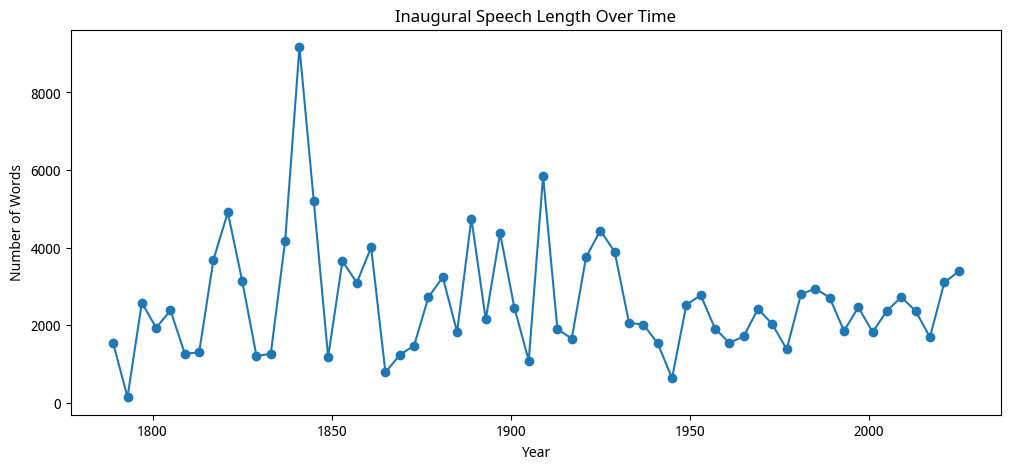

In [92]:
import matplotlib.pyplot as plt
from nltk.corpus import inaugural

years = []
word_counts = []

for fileid in inaugural.fileids():
    year = int(fileid[:4])
    count = len(inaugural.words(fileid))

    years.append(year)
    word_counts.append(count)

plt.figure(figsize=(12, 5))
plt.plot(years, word_counts, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Words")
plt.title("Inaugural Speech Length Over Time")
plt.show()

In [94]:
import nltk

nltk.download('twitter_samples')

from nltk.corpus import twitter_samples

print(twitter_samples.fileids())

tweets = twitter_samples.strings()

print(tweets[:5])

print("Total tweets:", len(tweets))

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']
['hopeless for tmr :(', "Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(", '@Hegelbon That heart sliding into the waste basket. :(', '“@ketchBurning: I hate Japanese call him "bani" :( :(”\n\nMe too', 'Dang starting next week I have "work" :(']
Total tweets: 30000


In [95]:
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')

words = []

for tweet in tweets:
    words.extend(word_tokenize(tweet))

print("Total words:", len(words))
print("Unique words:", len(set(words)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Total words: 660707
Unique words: 42639


**Text preprocessing**

In [103]:
sample_tweet = tweets[0]

print(sample_tweet)

hopeless for tmr :(


In [104]:
tokens = word_tokenize(sample_tweet)

print(tokens)

['hopeless', 'for', 'tmr', ':', '(']


In [105]:
lower_tokens = [word.lower() for word in tokens]

print(lower_tokens)

['hopeless', 'for', 'tmr', ':', '(']


In [106]:
clean_tokens = [word for word in lower_tokens if word.isalpha()]

print(clean_tokens)

['hopeless', 'for', 'tmr']


In [108]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

filtered_tokens = [
    word for word in clean_tokens
    if word not in stop_words
]

print(filtered_tokens)

['hopeless', 'tmr']


In [109]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in filtered_tokens
]

print(stemmed_words)

['hopeless', 'tmr']


In [110]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [111]:
lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

print(lemmatized_words)

['hopeless', 'tmr']


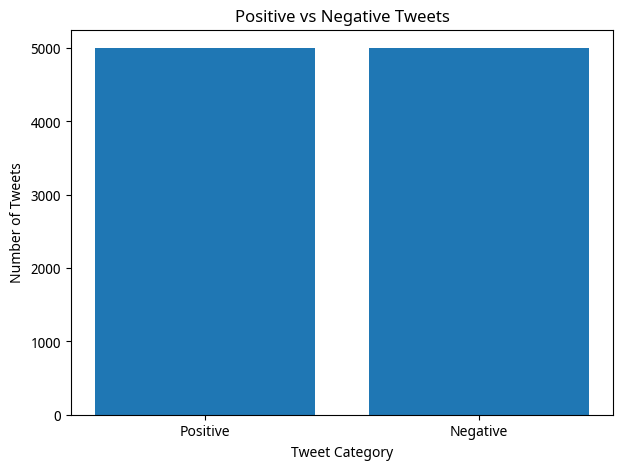

In [96]:
import matplotlib.pyplot as plt
from nltk.corpus import twitter_samples

categories = ['Positive', 'Negative']

counts = [
    len(twitter_samples.strings('positive_tweets.json')),
    len(twitter_samples.strings('negative_tweets.json'))
]

plt.figure(figsize=(7, 5))
plt.bar(categories, counts)

plt.xlabel("Tweet Category")
plt.ylabel("Number of Tweets")
plt.title("Positive vs Negative Tweets")

plt.show()

**5 NLTK Functions**

In [97]:
from nltk.corpus import webtext
from nltk.text import Text

print(webtext.fileids())

text = Text(webtext.words('firefox.txt'))

text.concordance("browser")

['firefox.txt', 'grail.txt', 'overheard.txt', 'pirates.txt', 'singles.txt', 'wine.txt']
Displaying 25 of 484 matches:
Pressing Ctrl - N should open a new browser when only download dialog is left o
ge ctrl + tab should switch tabs in browser favicon . ico colors render imprope
h fields . [ cust ] cancel is buggy Browser is ignoring the attibute TITLE in T
ected bookmark Add View -> Sidebars Browser Crash icons for customize toolbar a
hen Phoenix is checking for default browser NO is missing from the button Crash
work crash when closing main window browser long password can ' t work properly
window . Sorts are not reflected in browser window url drop - down box appears 
el link in the download manager the browser crashes if you open the link ( no j
ion : chevron appears when starting browser Tab prefs should allow changing new
tion while opening View page Source browser opened from About Phoenix is modal 
nu UI pref for changing behavior of browser windows reusage Extension preferenc
Ib

In [98]:
text.generate(length=50)

Building ngram index...


is Macromedia ? ( or Toplevel Element in XML ) Causes Autoscroll Icon
to Exhibit Undesirable Effects Offer to Save Password Occurs Too Soon
the form cannot submit quicksearch bookmarks should have tooltip
explanatory text Status bar check in View menu on ' download complete
. bar goes indefinately gray


"is Macromedia ? ( or Toplevel Element in XML ) Causes Autoscroll Icon\nto Exhibit Undesirable Effects Offer to Save Password Occurs Too Soon\nthe form cannot submit quicksearch bookmarks should have tooltip\nexplanatory text Status bar check in View menu on ' download complete\n. bar goes indefinately gray"

In [99]:
text.similar("browser")


firebird firefox new phoenix page the window open options url sidebar
theme download it mozilla tabs screen a tab toolbar


In [100]:
text.collocations()

http ://; new tab; context menu; address bar; Mozilla Firebird;
Download Manager; download manager; print preview; new window; Page
Info; Bookmarks Toolbar; Print Preview; status bar; location bar;
dialog box; DOM Inspector; personal toolbar; web page; Add Bookmark;
right click


In [101]:
text.index("browser")

34

In [102]:
from nltk.text import Text


text = Text(words)

text.concordance("hello", lines=10)

Displaying 10 of 74 matches:
rty goodbye stage : ( but this means Hello to Lion Heart and You Think @ MsDann
 and does n't want to : ( ( ( i miss hello venus 's old concepts tbh i rly like
 Feel better soon , Eris . # support Hello ; 3 geez .. i badly miss my 12 preci
 ( @ AllicioGloria She 's gone : ( , Hello , we offer you free perfume samples 
en failed : - ( @ vinrana1986 Say `` Hello '' to Viners Palembang please : ( @ 
 n't call him with : ( @ WeeklyChris Hello ! ... : ( Good news on the Boaz Myhi
s hopefully http : //t.co/uCSqlApqoX Hello my name is FlaviAna . : ( chickmt123
isakmr same : - ( @ GearIV @ Kodas_X hello i am spick and I find this offense :
 ( Alone : - ( : ' ( : -\ @ rcdlccom hello , any info about possible interest i
miss Chellos party : ( @ RCDeportivo hello , any info about possible interest i
